# Notebook 1: Dane i przetwarzanie wstępne

## Analiza sentymentu polskich recenzji produktów

**Autor:** [Twoje imię i nazwisko]

**Opis:** Projekt realizuje analizę sentymentu polskich recenzji produktów. Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na Transformerach (HerBERT).

**Źródło danych:** Zbiór `allegro-reviews` z Hugging Face Datasets – publicznie dostępny zbiór recenzji z serwisu Allegro z ocenami 1–5.

W tym notebooku:
1. Pobieramy i ładujemy dane
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

## 1. Instalacja i import bibliotek

In [14]:
!pip install datasets pandas matplotlib seaborn wordcloud spacy -q
!python -m spacy download pl_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 59.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Ustawienia wyświetlania
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

## 2. Pobranie i załadowanie danych

Korzystamy ze zbioru `allegro-reviews` dostępnego na Hugging Face. Zbiór zawiera polskie recenzje produktów z ocenami od 1 do 5.

In [16]:
spacy.load('pl_core_news_sm')
# Pobranie zbioru danych z Hugging Face
dataset = load_dataset("allegro_reviews", split="train")

# Konwersja do DataFrame
df = dataset.to_pandas()
print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {list(df.columns)}")
df.head()

Liczba rekordów: 9577
Kolumny: ['text', 'rating']


,text,rating
0,Jako do ceny dobra. Przyssawka mogłaby być lepsza. Po 2 miesiącach użytkowania musiałem nóżkę z przyssawką rozkręcić i przyssawkę podkleić bo guma zaczęła pękać od strony mocowania do uchwytu (uch...,3.0
1,"Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mimo to i tak czekałam znowu gdzie bardzo mi był...",1.0
2,"Czajnik na pierwszy rzut oka wygląda ok, ale nie polecam!!! Woda pomimo ciągłego gotowania nieprzyjemnie pachnie, czajnik był wygotowywany wielokrotnie w kwasku cytrynowym, sodzie, occie i nic nie...",1.0
3,"Bardzo fajny czajnik, na pewno nie gorszy od markowych jak Tefal czy Bosch. Trochę na początku czuć plastikiem, to mija. Ma wygodnie umieszczone przyciski - na górze, a nie na dole, co się przydaj...",4.0
4,Pomysł na produkt (uchwyt na kierownicę) bardzo dobry natomiast wykonanie uchwytu słabe. Po około 1-2 miesiącach sporadycznego użytkowania dolna częśc uchwytu po prostu się odrywa od reszty i uchw...,2.0


In [17]:
# Wybieramy kolumny: tekst recenzji i ocena (rating)
# Nazwy kolumn mogą się różnić - dostosuj jeśli trzeba
print("Podgląd kolumn i typów:")
print(df.dtypes)
print("\nPrzykładowe wartości:")
df.head(3)

Podgląd kolumn i typów:
text       object
rating    float32
dtype: object

Przykładowe wartości:


,text,rating
0,Jako do ceny dobra. Przyssawka mogłaby być lepsza. Po 2 miesiącach użytkowania musiałem nóżkę z przyssawką rozkręcić i przyssawkę podkleić bo guma zaczęła pękać od strony mocowania do uchwytu (uch...,3.0
1,"Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mimo to i tak czekałam znowu gdzie bardzo mi był...",1.0
2,"Czajnik na pierwszy rzut oka wygląda ok, ale nie polecam!!! Woda pomimo ciągłego gotowania nieprzyjemnie pachnie, czajnik był wygotowywany wielokrotnie w kwasku cytrynowym, sodzie, occie i nic nie...",1.0


In [18]:
# Mapowanie ocen na sentyment (binarny)
# 1-2 -> negatywny (0), 4-5 -> pozytywny (1), 3 -> neutralny (pomijamy)
df_binary = df.copy()

# Dostosuj nazwy kolumn do faktycznych nazw w zbiorze
TEXT_COL = "text"  # <- zmień jeśli kolumna nazywa się inaczej
RATING_COL = "rating"  # <- zmień jeśli kolumna nazywa się inaczej


def map_sentiment(rating):
    """Mapuje ocenę liczbową na etykietę sentymentu."""
    if rating <= 2:
        return 0  # negatywny
    elif rating >= 4:
        return 1  # pozytywny
    else:
        return -1  # neutralny - do odrzucenia


df_binary["sentiment"] = df_binary[RATING_COL].apply(map_sentiment)
df_binary = df_binary[df_binary["sentiment"] != -1].reset_index(drop=True)

print(f"Liczba rekordów po filtracji (bez neutralnych): {len(df_binary)}")
print(f"\nRozkład sentymentu:")
print(df_binary["sentiment"].value_counts())

Liczba rekordów po filtracji (bez neutralnych): 8369

Rozkład sentymentu:
sentiment
1    5567
0    2802
Name: count, dtype: int64


## 3. Eksploracyjna analiza danych (EDA)

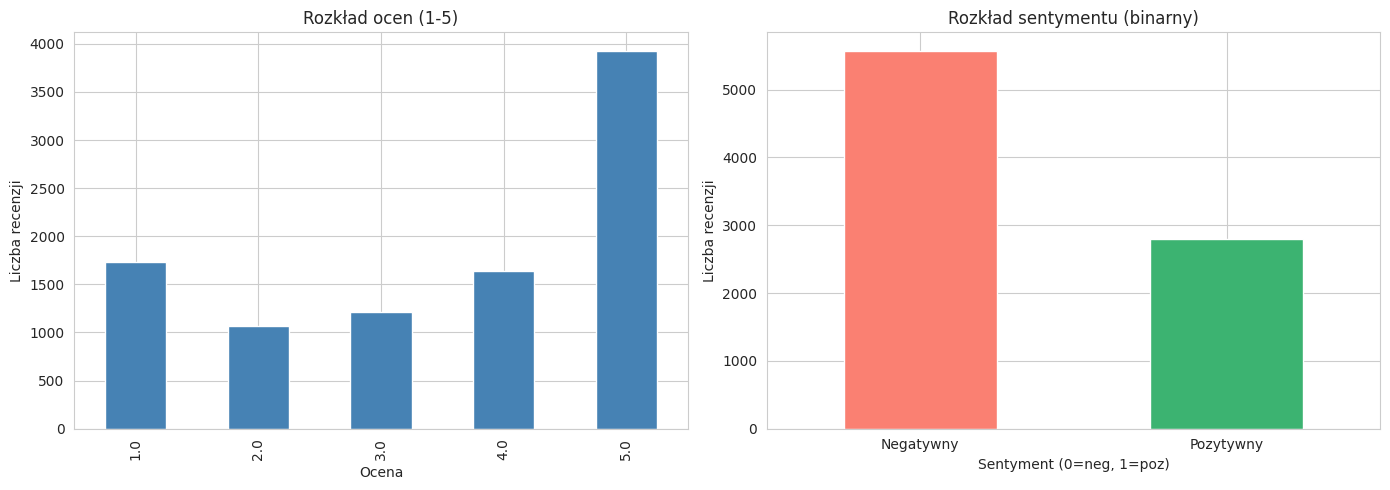

In [19]:
# Rozkład ocen w oryginalnym zbiorze
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rozkład oryginalnych ocen
df[RATING_COL].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Rozkład ocen (1-5)")
axes[0].set_xlabel("Ocena")
axes[0].set_ylabel("Liczba recenzji")

# Rozkład sentymentu binarnego
df_binary["sentiment"].value_counts().plot(
    kind="bar", ax=axes[1], color=["salmon", "mediumseagreen"]
)
axes[1].set_title("Rozkład sentymentu (binarny)")
axes[1].set_xlabel("Sentyment (0=neg, 1=poz)")
axes[1].set_ylabel("Liczba recenzji")
axes[1].set_xticklabels(["Negatywny", "Pozytywny"], rotation=0)

plt.tight_layout()
plt.show()

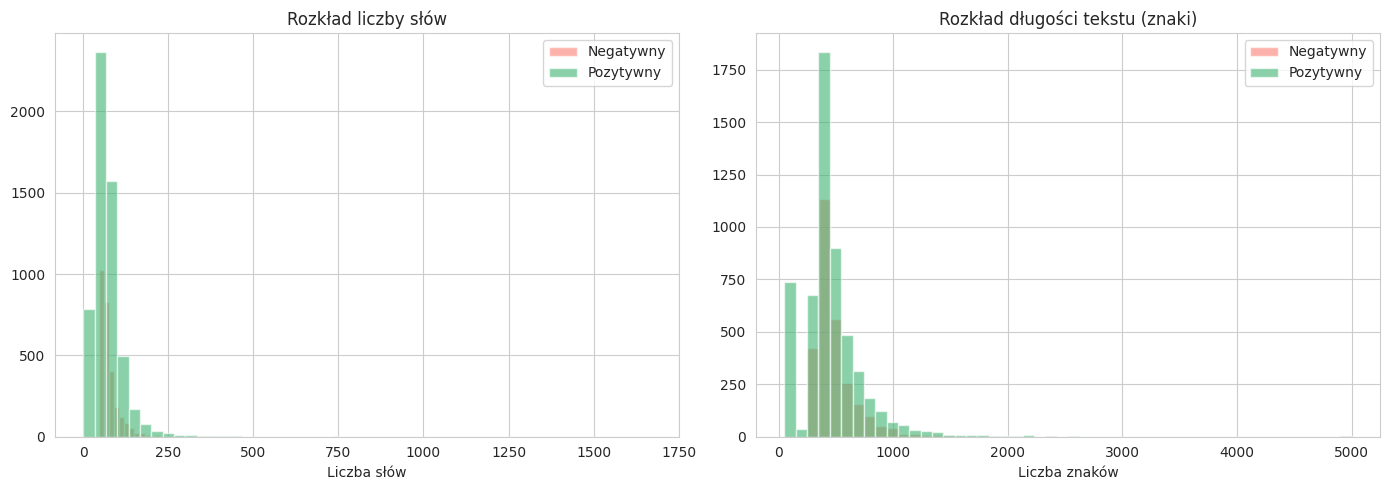

Statystyki długości recenzji (słowa):
            count       mean        std  min   25%   50%   75%     max
sentiment                                                             
0          2802.0  76.435403  37.543048  0.0  56.0  66.0  83.0   752.0
1          5567.0  69.275912  51.789695  0.0  53.0  63.0  82.5  1667.0


In [20]:
# Długość recenzji
df_binary["text_length"] = df_binary[TEXT_COL].astype(str).apply(len)
df_binary["word_count"] = df_binary[TEXT_COL].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color, label in [(0, "salmon", "Negatywny"), (1, "mediumseagreen", "Pozytywny")]:
    subset = df_binary[df_binary["sentiment"] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki)")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości recenzji (słowa):")
print(df_binary.groupby("sentiment")["word_count"].describe())

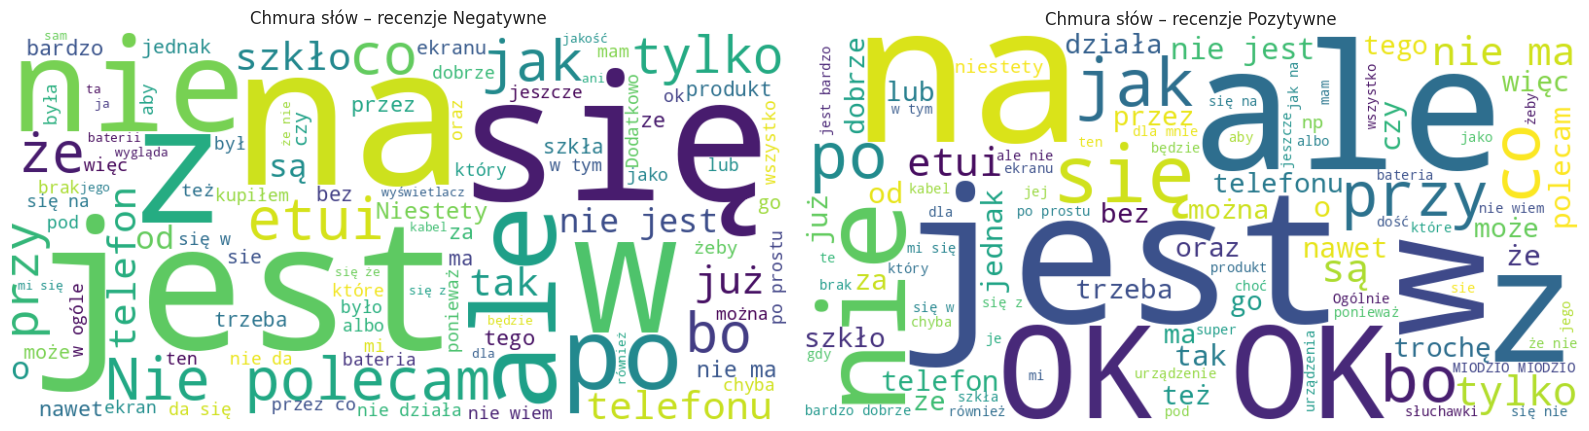

In [21]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(0, "Negatywne"), (1, "Pozytywne")]):
    texts = " ".join(df_binary[df_binary["sentiment"] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – recenzje {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. Przetwarzanie wstępne tekstu

In [22]:
# Ładowanie modelu spaCy dla języka polskiego
nlp = spacy.load("pl_core_news_sm", disable=["ner", "parser"])


def preprocess_text(text):
    """Przetwarzanie wstępne tekstu: czyszczenie, lematyzacja, usunięcie stopwords."""
    if not isinstance(text, str):
        return ""

    # Zamiana na małe litery
    text = text.lower()

    # Usunięcie URL-i
    text = re.sub(r"http\S+|www\S+", "", text)

    # Usunięcie tagów HTML
    text = re.sub(r"<.*?>", "", text)

    # Usunięcie znaków specjalnych (zostawiamy litery i spacje)
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", "", text)

    # Lematyzacja i usunięcie stopwords za pomocą spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and len(token.text) > 1
    ]

    return " ".join(tokens)


# Przykład działania
sample_text = df_binary[TEXT_COL].iloc[0]
print(f"Oryginał: {sample_text[:200]}")
print(f"\nPo przetworzeniu: {preprocess_text(sample_text)[:200]}")

Oryginał: Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mimo to i tak czekałam znowu gdzie bardzo mi była po

Po przetworzeniu: słuchawka czekać być spór czas zadzwonienie okazać paczka zawieruszyć dzień mieć wysłać najszybszym kurier czekać być potrzebny niby bateria trzymać długo słuchawka rozłącz dostać być ponownie wiadomo


In [23]:
# Przetwarzanie wstępne dla podejścia klasycznego
# (Transformer będzie korzystał z surowego tekstu)
print("Przetwarzanie tekstu... (może potrwać kilka minut)")
df_binary["text_clean"] = df_binary[TEXT_COL].astype(str).apply(preprocess_text)

# Usunięcie pustych rekordów po przetworzeniu
df_binary = df_binary[df_binary["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Rekordów po przetworzeniu: {len(df_binary)}")

Przetwarzanie tekstu... (może potrwać kilka minut)
Rekordów po przetworzeniu: 8364


## 5. Podział na zbiory treningowy, walidacyjny i testowy

In [24]:
# Ograniczenie do rozsądnej liczby przykładów (Google Colab ma limity pamięci)
MAX_SAMPLES = 5000

if len(df_binary) > MAX_SAMPLES:
    df_sample = df_binary.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Losowo wybrano {MAX_SAMPLES} próbek z {len(df_binary)}")
else:
    df_sample = df_binary.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek")

# Podział: 70% trening, 15% walidacja, 15% test
train_df, temp_df = train_test_split(
    df_sample, test_size=0.3, random_state=42, stratify=df_sample["sentiment"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["sentiment"]
)

print(f"\nRozmiary zbiorów:")
print(f"  Treningowy: {len(train_df)}")
print(f"  Walidacyjny: {len(val_df)}")
print(f"  Testowy: {len(test_df)}")

print(f"\nRozkład sentymentu w zbiorze treningowym:")
print(train_df["sentiment"].value_counts(normalize=True))

Losowo wybrano 5000 próbek z 8364

Rozmiary zbiorów:
  Treningowy: 3500
  Walidacyjny: 750
  Testowy: 750

Rozkład sentymentu w zbiorze treningowym:
sentiment
1    0.663143
0    0.336857
Name: proportion, dtype: float64


In [25]:
# Zapis przetworzonych danych do plików CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nKolumny w pliku:")
print(f"  '{TEXT_COL}' - oryginalny tekst (dla Transformerów)")
print(f"  'text_clean' - przetworzony tekst (dla podejścia klasycznego)")
print(f"  'sentiment' - etykieta (0=negatywny, 1=pozytywny)")

Dane zapisane do plików: train.csv, val.csv, test.csv

Kolumny w pliku:
  'text' - oryginalny tekst (dla Transformerów)
  'text_clean' - przetworzony tekst (dla podejścia klasycznego)
  'sentiment' - etykieta (0=negatywny, 1=pozytywny)


## Podsumowanie

W tym notebooku:
- Pobraliśmy zbiór polskich recenzji z Allegro (Hugging Face)
- Zamieniliśmy oceny na sentyment binarny (pozytywny/negatywny)
- Przeprowadziliśmy EDA: rozkłady ocen, długości recenzji, chmury słów
- Wykonaliśmy przetwarzanie wstępne: czyszczenie, lematyzacja, usunięcie stopwords
- Podzieliliśmy dane na zbiory: train (70%), val (15%), test (15%)

Dane są gotowe do użycia w kolejnych notebookach.